# Problem 2: 
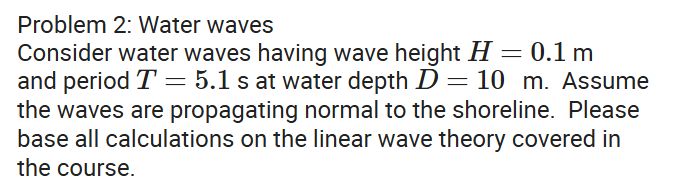

In [1]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from scipy.integrate import solve_ivp

In [2]:
# Given data
# Given data
g = 9.81                    # gravitational acceleration (m/s^2)
viscosity = 1.3*10**-6      # kinematic viscosity of water (m^2/s)    
rho_water = 1000            # density of water (kg/m^3)
kappa = 0.4                 # von Karman constant
rho_air = 1.2               # air density (kg/m^3)
viscosity_air = 1.5*10**-5  # kinematic viscosity of air (m^2/s) 

H = 0.1 
T = 5.1
D = 10

#### Question 2.1
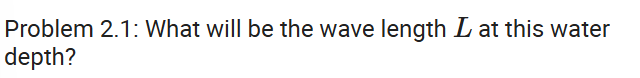

In [3]:
omega = 2 * np.pi / T        # (1/s) Wave angular frequency
k0 = omega**2 / g            # Initial guess for wavenumber

# Solve dispersion relation
func = lambda k0: omega**2 - g * k0 * np.tanh(k0 * D)
k = fsolve(func, k0)
k = k[0]

L = 2 * np.pi / k      # Wavelength
print(f"Wavelength L: {L:.0f} m")
print(f"Wavenumber k: {k:.4f} 1/m")

Wavelength L: 38 m
Wavenumber k: 0.1663 1/m


In [6]:
kD = k*D # intermediate water
print("kD: ",kD)

kD:  1.662646839572019


#### Question 2.2
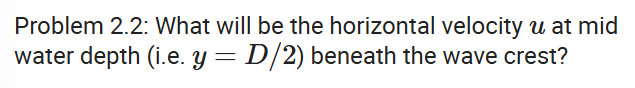

In [7]:
y_bed = D/2            # y-coordinate at the sea bed

# Velocity at the sea bed beaneth the wave trough (y = -D)  <--- -1 in the equation means the trough
u_at_y = lambda y: H/2 * omega * np.cosh(k*y)/np.sinh(k*D)   # Velocity at depth y


# Print results
print(f"Maximum horizonral velocity at the bed: {u_at_y(y_bed):.3f} m/s")

Maximum horizonral velocity at the bed: 0.033 m/s


#### Question 2.3
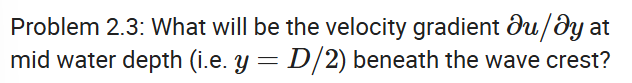

In [21]:
from scipy.integrate import quad
# Displacement thickness at t=0
def integrand(y):
    y = D/2
    u_at_y = H/2 * omega * np.cosh(k*y)/np.sinh(k*D)
    return u_at_y

# Calculate the displacement thickess
gradient, _ = quad(integrand, 0, np.inf)      # result, estimated error

# Print the result
print(f"Gradient: {gradient:.4f} m")


Displacement thickness at t=0: -0.0054 m


C:\Users\natal\AppData\Local\Temp\ipykernel_41548\3881770814.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  gradient, _ = quad(integrand, 0, np.inf)      # result, estimated error


#### Question 2.4
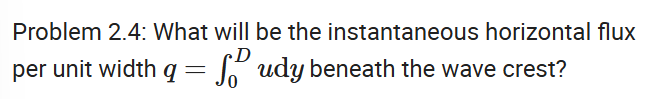

In [24]:
from scipy.integrate import quad
# Displacement thickness at t=0
def integrand(y):
    y = 0
    u_at_y = H/2 * omega * np.cosh(k*y)/np.sinh(k*D)
    return u_at_y

# Calculate the displacement thickess
flux, _ = quad(integrand, 0, np.inf)      # result, estimated error

# Print the result
print(f"Horizontal flux: {flux:.4f} m")


Horizontal flux: -0.0006 m


C:\Users\natal\AppData\Local\Temp\ipykernel_41548\2587881399.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  flux, _ = quad(integrand, 0, np.inf)      # result, estimated error


In [23]:
E = 1/8 * rho_water * g * H**2
print(E)

26.43300335729228


#### Question 2.5
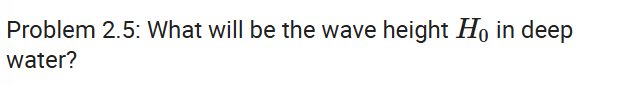

In [13]:
L_0 = g * T**2 / (2 * np.pi)                    # deep water wave length [m]
k_0 = 2 * np.pi / L_0                           # deep water wave number [m^-1]
c_0 = np.sqrt(g / k_0)                          # deep water wave celerity [m/s]

G = 2*k*D / np.sinh(2*k*D)
H_0 = np.sqrt(H**2 * (1 + G) * np.tanh(k * D))
print(f"Deep water Wave Height {H_0:.2f} m")

Deep water Wave Height 0.11 m


#### Question 2.6 
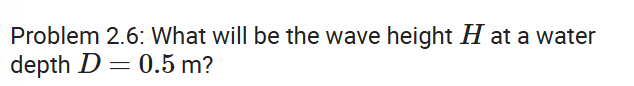

In [18]:
DEPTH = 0.5

def water_condition(H, k, D):
    if k*D > np.pi:
        return "Deep water"
    elif k*D < np.pi/10:
        return "Shallow water"
    else:
        return "Intermediate water"
    
# Print the reults
print(f"Water condition at D={DEPTH} m: {water_condition(H, k, DEPTH)}")

Water condition at D=0.5 m: Shallow water


In [19]:
DEPTH = 0.5
alpha_0 = 0

# ----------------------------------------------
# Functions to obtain wave height at deep water
# ----------------------------------------------

def Snell_law (alpha, alpha_0, k, k_0):                                    # Snell's law
    return np.sin(alpha)*k - np.sin(alpha_0)*k_0

def cons_energy_flux (H, H_0, k, D, alpha, alpha_0): #energy flux conservation with refraction
    G = 2*k*D / np.sinh(2*k*D)
    K_s = np.sqrt(1.0 /(np.tanh(k*D) * (1.0+G)))
    K_r = np.sqrt(np.cos(alpha_0)/np.cos(alpha))
    return H - H_0*K_r*K_s

def dispersion(k, D, T):                                                   # Dispersion relation
    omega = 2*np.pi/T
    return omega**2 - g * k * np.tanh(k*D)

def refraction(D, H_0, k_0, alpha_0, T):
    def system(x):
        H, k, alpha = x
        return np.array([cons_energy_flux(H, H_0, k, D, alpha, alpha_0),dispersion(k, D, T), Snell_law(alpha, alpha_0, k, k_0)], dtype=float)
    
    H, k, alpha = fsolve(system, x0=[H_0, k_0, alpha_0])
    return H, k, alpha


# Print the reults
H, k, alpha = refraction(DEPTH, H_0, k_0, alpha_0, T)
print(f"Wave height at D={DEPTH} m: {H:.2f} m")

Wave height at D=0.5 m: 0.15 m
